
## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r'C:\Users\ASUS\Desktop\churn-prediction')
print(os.getcwd())  # confirm it's the project root

C:\Users\ASUS\Desktop\churn-prediction


## 2. Load Raw Data

In [2]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
df['Churn'].value_counts(normalize=True) * 100  # check class imbalance

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## 3. Data Cleaning

**TotalCharges** was loaded as text (object) instead of numeric, because 11 rows contain a blank space `' '` instead of a number — these are customers with `tenure = 0` (brand new, no charges yet).

In [7]:
df[df['TotalCharges'] == ' ']  # inspect the problem rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # blanks become NaN

In [9]:
df['TotalCharges'].isna().sum()  # confirm 11 NaNs

np.int64(11)

In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # fill with 0 (no charges yet)

In [11]:
df['TotalCharges'].dtype  # confirm now float64

dtype('float64')

## 4. Save Checkpoint
Save the cleaned dataframe so future sessions can reload instantly without re-running cleaning steps.

In [12]:
os.makedirs('data', exist_ok=True)
df.to_pickle('data/cleaned_churn_data.pkl')

## 5. EDA 

**Reload point:** if you're starting a new session, run the cell below instead of Sections 1-4 above.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r'C:\Users\ASUS\Desktop\churn-prediction')
df = pd.read_pickle('data/cleaned_churn_data.pkl')

### 5.1 Churn Rate by Contract Type

In [3]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


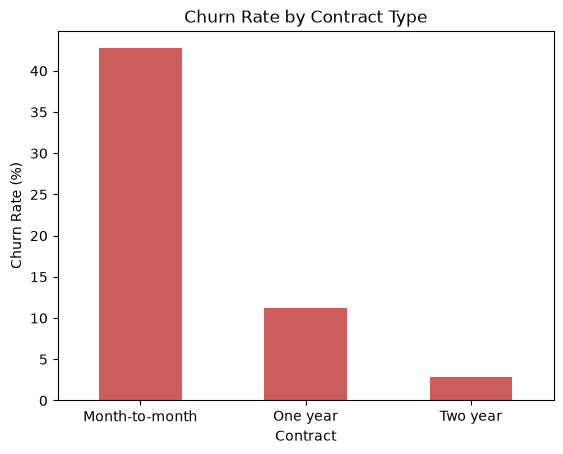

In [4]:
contract_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='indianred')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.savefig('images/churn_by_contract.png', bbox_inches='tight')
plt.show()

**Finding:** Month-to-month customers churn at 42.7%, vs 11.3% for one-year and just 2.8% for two-year contracts.

**Implication:** Contract length is one of the strongest churn predictors in this dataset. Customers with no lock-in have far less friction to leave. This suggests the business could reduce churn significantly by incentivizing upgrades from month-to-month to annual/two-year plans-e.g. discounts for longer commitments, bundling perks, or proactive retention offers targeted specifically at the month-to-month segment (since that's also likely the largest group by volume).

### 5.2 Churn vs Tenure

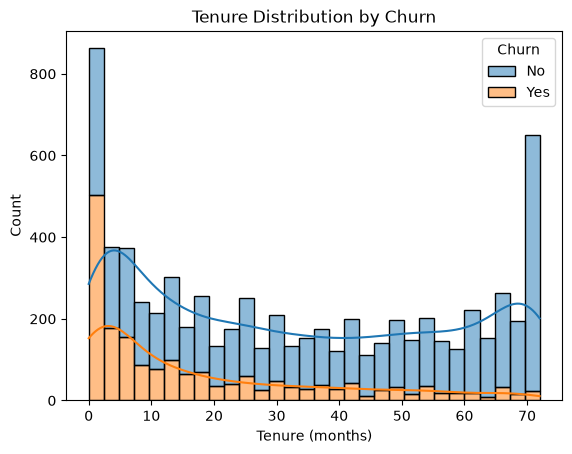

In [5]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, multiple='stack')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.savefig('images/tenure_by_churn.png', bbox_inches='tight')
plt.show()

**Finding:** Churn is heavily concentrated among low-tenure customers (first few months). Customers who reach 5-6 years of tenure churn almost never.

**Implication:** The highest-risk window is the early relationship period. Investing in onboarding/early engagement is likely more impactful than targeting already-loyal, long-tenure customers. Possibly linked to Contract Type finding above-new customers are likely disproportionately month-to-month.

### 5.3 Churn vs Monthly Charges


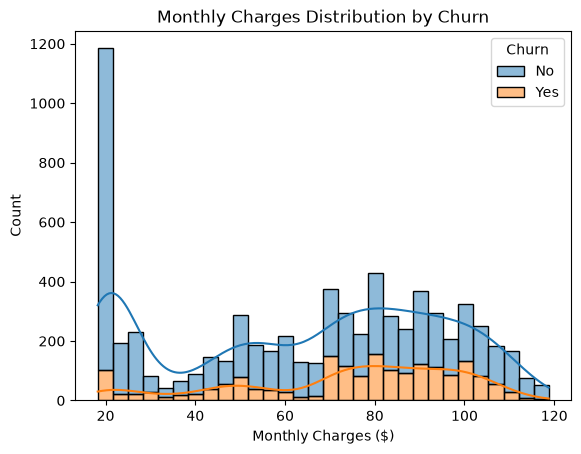

In [6]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, multiple='stack')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')
plt.savefig('images/charges_by_churn.png', bbox_inches='tight')
plt.show()

**Finding**: Churn is proportionally concentrated among customers with higher monthly charges (~$70-100/month), while very low-bill customers (~$20, likely single-service subscribers) show minimal churn.

**Implication**: Customers with larger bills may feel they're not getting proportional value, or higher charges may correlate with bundled add-on services (e.g. streaming, security) that aren't sticky. This ties into Contract Type and Tenure too-worth checking later whether high-monthly-charge customers are disproportionately month-to-month and low-tenure, which would suggest it's really one combined risk profile (new + uncommitted + expensive) rather than three separate factors.

### 5.4 Monthly Charges — Boxplot View

A boxplot gives a more compact comparison of the two groups' charge distributions-median, spread, and outliers at a glance, alongside the histogram above.

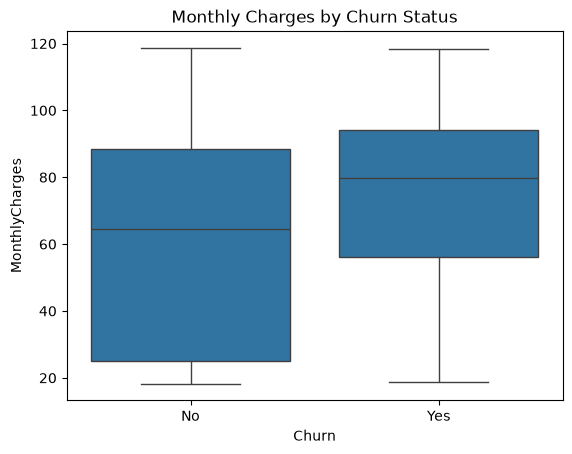

In [7]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.savefig('images/charges_boxplot.png', bbox_inches='tight')
plt.show()

**Finding**: Churned customers have a higher median monthly charge (~$80) than retained customers (~$65), and their charges are more tightly clustered in the $57-94 range while retained customers span a much wider range including many low-charge customers.

**Implication**: Confirms the histogram higher monthly charges are associated with higher churn risk. Retained customers include a large low-cost segment (likely single-service subscribers) who rarely leave. This strengthens the earlier hypothesis: churn risk may cluster around a specific customer profile new, month-to-month, higher-paying rather than being three unrelated factors.